# Diabetes classification: Logistic Regression vs Neural Network

- **Part A:** Logistic regression (Project 1)
- **Part B:** Neural network
- **Part C:** Paired comparison on the same test set with McNemar's test

---
# Part A: Logistic Regression

# Project 1 – XAI: Logistic Regression on diabetes data
Simple setup: 80/20 train/test split, standardization, sklearn `LogisticRegression` trained epoch by epoch with early stopping, followed by testing and loss evaluation.

## 1. Setup

In [2]:
import numpy as np
import pandas as pd
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, confusion_matrix, classification_report
from sklearn.exceptions import ConvergenceWarning
import matplotlib.pyplot as plt
import seaborn as sns

# we deliberately run 1 iteration per call, so sklearn will warn every time - hide that
warnings.filterwarnings("ignore", category=ConvergenceWarning)

### Adjustable parameters

In [3]:
# split
test_size = 0.20          # 80/20 train/test
val_size = 0.20           # fraction of the TRAINING data used for validation (early stopping)
seed = 42                 # same seed as the neural network -> identical train/val/test split

# training
max_epochs = 100
C_reg = 1.0               # inverse regularization strength (smaller = stronger regularization)

# early stopping
patience = 5              # epochs without improvement before stopping
min_delta = 1e-5          # minimum decrease in val loss to count as an improvement

In [4]:
# Load data
df = pd.read_csv("diabetes_binary_5050split_health_indicators_BRFSS2015.csv")

feature_names = list(df.columns)
feature_names.remove("Diabetes_binary")

X = df[feature_names].values
y = df["Diabetes_binary"].values.astype(int)

print(f"X: {X.shape}, y: {y.shape}")
print(f"Classes: {np.bincount(y)}")

X: (70692, 21), y: (70692,)
Classes: [35346 35346]


In [5]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


### Train/test split (80/20)
The test set is not touched until the end. Early stopping needs data the model is not trained on, so a validation set is taken out of the training data.

In [6]:
# 80/20 split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=seed, stratify=y)

# validation set taken from the training data
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_raw, y_train, test_size=val_size, random_state=seed, stratify=y_train)

print(f"Train: {X_train_raw.shape[0]}, Val: {X_val_raw.shape[0]}, Test: {X_test_raw.shape[0]}")

Train: 45242, Val: 11311, Test: 14139


### Standardization
Mean and std are computed on the training data only and then applied to val and test, so no information leaks from the test set.

In [7]:
train_mean = np.mean(X_train_raw, axis=0)
train_std = np.std(X_train_raw, axis=0)

X_train = (X_train_raw - train_mean) / train_std
X_val = (X_val_raw - train_mean) / train_std
X_test = (X_test_raw - train_mean) / train_std

print("Train mean:", np.round(np.mean(X_train, axis=0), 3))
print("Train std: ", np.round(np.std(X_train, axis=0), 3))

Train mean: [-0. -0.  0.  0. -0.  0.  0. -0.  0.  0.  0. -0. -0.  0. -0. -0.  0.  0.
  0.  0. -0.]
Train std:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 2. Run (training with early stopping)
sklearn's `LogisticRegression` has no built-in early stopping. Instead we use:
- `max_iter=1`, so each call to `.fit()` performs one optimization step (we call each step an epoch)
- `warm_start=True`, so each call continues from the previous weights instead of starting over

After each epoch the log loss on the validation set is computed. If it has not improved by at least `min_delta` for `patience` epochs, training stops and the best weights are restored.

In [8]:
model = LogisticRegression(solver='lbfgs', max_iter=1, warm_start=True,
                           C=C_reg, random_state=seed)

train_losses = []
val_losses = []

best_val_loss = np.inf
best_coef = None
best_intercept = None
best_epoch = 0
epochs_without_improvement = 0

for epoch in range(max_epochs):
    # one epoch of training
    model.fit(X_train, y_train)

    # loss on train and validation
    train_loss = log_loss(y_train, model.predict_proba(X_train))
    val_loss = log_loss(y_val, model.predict_proba(X_val))
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # early stopping check
    if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        best_coef = model.coef_.copy()
        best_intercept = model.intercept_.copy()
        best_epoch = epoch
        epochs_without_improvement = 0
    else:
        epochs_without_improvement = epochs_without_improvement + 1

    if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

# restore the best weights
model.coef_ = best_coef
model.intercept_ = best_intercept

print(f"Best epoch: {best_epoch}, val loss: {best_val_loss:.4f}")

Early stopping at epoch 11
Best epoch: 6, val loss: 0.5084


## 3. Testing

In [9]:
train_pred = model.predict(X_train)
val_pred = model.predict(X_val)
test_pred = model.predict(X_test)

train_acc = np.mean(train_pred == y_train)
val_acc = np.mean(val_pred == y_val)
test_acc_logistic = np.mean(test_pred == y_test)

print(f"Train accuracy: {train_acc:.3f}")
print(f"Val accuracy:   {val_acc:.3f}")
print(f"Test accuracy:  {test_acc_logistic:.3f}")

Train accuracy: 0.748
Val accuracy:   0.752
Test accuracy:  0.746


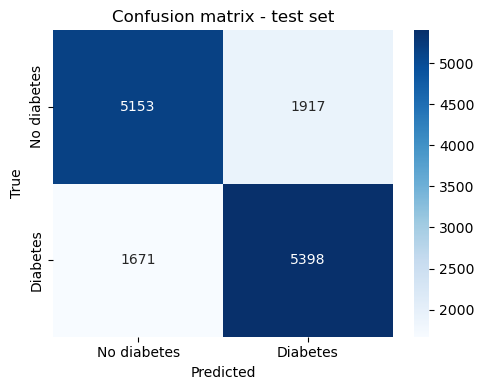

              precision    recall  f1-score   support

 No diabetes       0.76      0.73      0.74      7070
    Diabetes       0.74      0.76      0.75      7069

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



In [10]:
# Confusion matrix + classification report on the test set
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No diabetes', 'Diabetes'],
            yticklabels=['No diabetes', 'Diabetes'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion matrix - test set')
plt.tight_layout()
plt.show()

print(classification_report(y_test, test_pred, target_names=['No diabetes', 'Diabetes']))

## 4. Loss evaluation

In [11]:
# final loss on each set (with the best weights)
final_train_loss = log_loss(y_train, model.predict_proba(X_train))
final_val_loss = log_loss(y_val, model.predict_proba(X_val))
final_test_loss = log_loss(y_test, model.predict_proba(X_test))

print(f"Train loss: {final_train_loss:.4f}")
print(f"Val loss:   {final_val_loss:.4f}")
print(f"Test loss:  {final_test_loss:.4f}")

Train loss: 0.5125
Val loss:   0.5084
Test loss:  0.5137


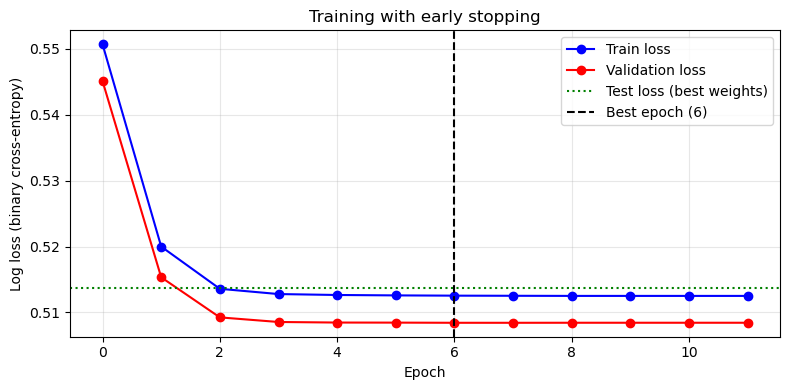

In [12]:
# Loss curves
epochs = np.arange(len(train_losses))

plt.figure(figsize=(8, 4))
plt.plot(epochs, train_losses, 'o-', label='Train loss', color='blue')
plt.plot(epochs, val_losses, 'o-', label='Validation loss', color='red')
plt.axhline(final_test_loss, color='green', linestyle=':', label='Test loss (best weights)')
plt.axvline(best_epoch, color='black', linestyle='--', label=f'Best epoch ({best_epoch})')
plt.xlabel('Epoch')
plt.ylabel('Log loss (binary cross-entropy)')
plt.title('Training with early stopping')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# Save the logistic regression results before Part B overwrites names like model and y_test
lr_model = model
lr_test_pred = test_pred.copy()
lr_y_test = y_test.copy()

---
# Part B: Neural Network

# Simple neural network for diabetes classification

A small baseline neural network for the diabetes-risk assignment.

- **Target:** `Diabetes_binary`
- **Inputs:** 21 health-indicator features
- **Architecture:** 21 → 32 → 16 → 1
- **Loss:** `BCEWithLogitsLoss`
- **Evaluation:** validation set during training, untouched test set at the end

The model is intentionally kept simple so it can be expanded later for XAI analysis.


In [14]:
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


In [15]:
# Loads the dataset
df = pd.read_csv("diabetes_binary_5050split_health_indicators_BRFSS2015.csv")

print("Dataset shape:", df.shape)
display(df.head())

print("\nTarget distribution:")
print(df["Diabetes_binary"].value_counts())


Dataset shape: (70692, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0



Target distribution:
Diabetes_binary
0.0    35346
1.0    35346
Name: count, dtype: int64


In [16]:
# Separate features and target
target_col = "Diabetes_binary"

X = df.drop(columns=[target_col]).to_numpy(dtype=np.float32)
y = df[target_col].to_numpy(dtype=np.float32)

feature_names = df.drop(columns=[target_col]).columns.tolist()

# Keeps 20% completely separate for final testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y #maintains approximately the same proportion of classes in both datasets.
)

# Make a validation set from the remaining data
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train
)

# Standardize using training data only 
# (If we calculated the mean and standard deviation using all the data, information from the test set would leak into the training process.)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val = scaler.transform(X_val).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

print("Number of features:", X_train.shape[1])
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Number of features: 21
Train: (45242, 21)
Validation: (11311, 21)
Test: (14139, 21)


In [17]:
# Convert data to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

batch_size = 256

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t),
    batch_size=batch_size,
    shuffle=False
)


In [18]:
# This is our neural network (small and simple)

class DiabetesNN(nn.Module):
    def __init__(self, n_features):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(n_features, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)


model = DiabetesNN(n_features=X_train.shape[1])

# BCEWithLogitsLoss already includes the sigmoid operation internally
# BCE = Binary Cross Entropy
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [19]:
# Train the model with simple early stopping

max_epochs = 100 #1 epoch = The neural network has seen every training observation once.
patience = 5 #If validation loss doesn't improve for 5 consecutive epochs, stop training.

best_val_loss = float("inf")
epochs_without_improvement = 0
best_model_state = None

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(max_epochs):

    # ----- Training -----
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

        predictions = (torch.sigmoid(logits) >= 0.5).float()
        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)

    train_loss = running_loss / total
    train_accuracy = correct / total

    # ----- Validation -----
    model.eval()
    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            running_val_loss += loss.item() * X_batch.size(0)

            predictions = (torch.sigmoid(logits) >= 0.5).float()
            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

    val_loss = running_val_loss / total
    val_accuracy = correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch {epoch + 1:02d} | "
        f"train loss: {train_loss:.4f} | "
        f"val loss: {val_loss:.4f} | "
        f"train acc: {train_accuracy:.3f} | "
        f"val acc: {val_accuracy:.3f}"
    )

    # ----- Early stopping -----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break

# Use the weights from the epoch with the lowest validation loss
model.load_state_dict(best_model_state)


Epoch 01 | train loss: 0.5673 | val loss: 0.5091 | train acc: 0.714 | val acc: 0.751
Epoch 02 | train loss: 0.5088 | val loss: 0.5051 | train acc: 0.750 | val acc: 0.753
Epoch 03 | train loss: 0.5060 | val loss: 0.5044 | train acc: 0.751 | val acc: 0.751
Epoch 04 | train loss: 0.5044 | val loss: 0.5036 | train acc: 0.753 | val acc: 0.751
Epoch 05 | train loss: 0.5031 | val loss: 0.5023 | train acc: 0.753 | val acc: 0.752
Epoch 06 | train loss: 0.5018 | val loss: 0.5021 | train acc: 0.754 | val acc: 0.752
Epoch 07 | train loss: 0.5010 | val loss: 0.5018 | train acc: 0.756 | val acc: 0.751
Epoch 08 | train loss: 0.5002 | val loss: 0.5021 | train acc: 0.756 | val acc: 0.752
Epoch 09 | train loss: 0.5000 | val loss: 0.5021 | train acc: 0.757 | val acc: 0.753
Epoch 10 | train loss: 0.4993 | val loss: 0.5015 | train acc: 0.756 | val acc: 0.754
Epoch 11 | train loss: 0.4990 | val loss: 0.5015 | train acc: 0.756 | val acc: 0.753
Epoch 12 | train loss: 0.4986 | val loss: 0.5013 | train acc: 0.7

<All keys matched successfully>

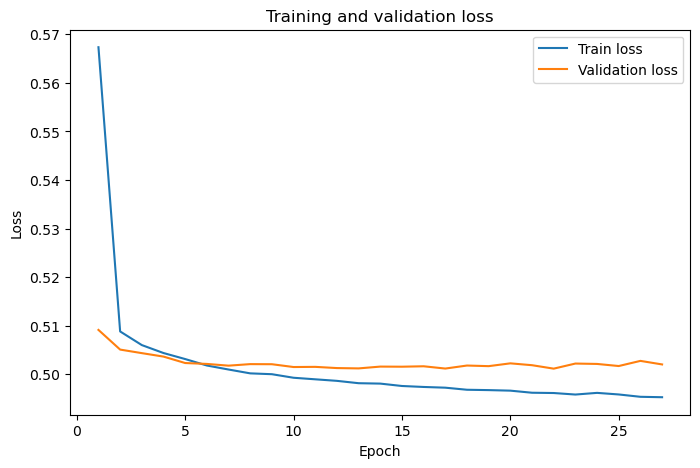

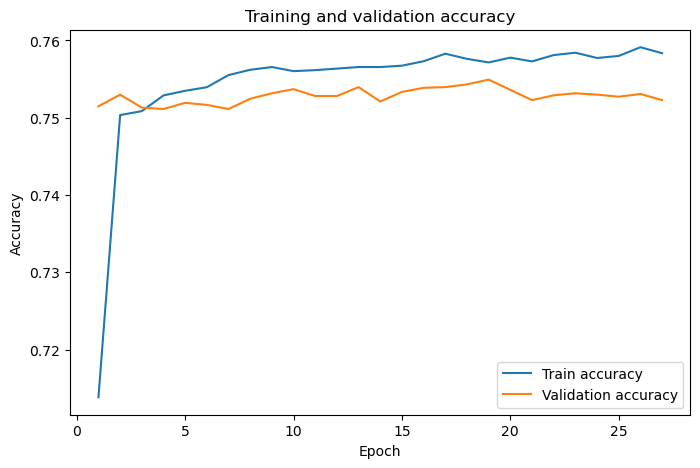

In [20]:
# Plot learning curves
epochs_run = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_run, train_losses, label="Train loss")
plt.plot(epochs_run, val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_run, train_accuracies, label="Train accuracy")
plt.plot(epochs_run, val_accuracies, label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.show()


In [21]:
# Evaluation once on the untouched test set
model.eval()

with torch.no_grad():
    test_logits = model(X_test_t)
    test_probabilities = torch.sigmoid(test_logits).cpu().numpy().ravel()

test_predictions = (test_probabilities >= 0.5).astype(int)

test_accuracy_nn = accuracy_score(y_test, test_predictions)
test_auc = roc_auc_score(y_test, test_probabilities)

print(f"Test accuracy: {test_accuracy_nn:.3f}")
print(f"ROC-AUC:       {test_auc:.3f}")

print("\nClassification report:")
print(classification_report(y_test, test_predictions, digits=3))


Test accuracy: 0.750
ROC-AUC:       0.829

Classification report:
              precision    recall  f1-score   support

         0.0      0.778     0.701     0.737      7070
         1.0      0.728     0.800     0.762      7069

    accuracy                          0.750     14139
   macro avg      0.753     0.750     0.750     14139
weighted avg      0.753     0.750     0.750     14139



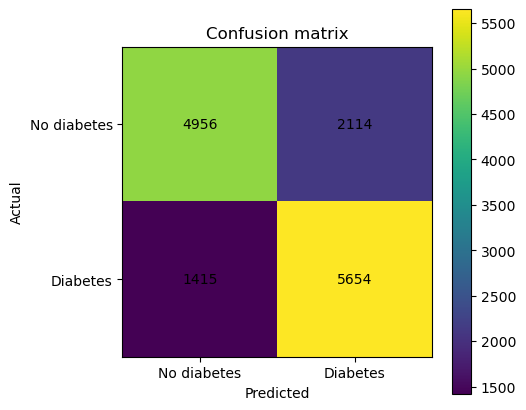

In [22]:
# Confusion matrix
cm = confusion_matrix(y_test, test_predictions)

fig, ax = plt.subplots(figsize=(5, 5))
image = ax.imshow(cm)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["No diabetes", "Diabetes"])
ax.set_yticklabels(["No diabetes", "Diabetes"])

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion matrix")

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar(image, ax=ax)
plt.show()


In [23]:
# Save the neural network results
nn_model = model
nn_test_pred = test_predictions.copy()
nn_y_test = y_test.copy()

---
# Part C: McNemar's test (paired, same test set)

Same setup as in the data analysis notebook. For each test observation we record whether each model classified it **correctly** (1) or **wrongly** (0). McNemar only uses the discordant pairs, i.e. observations where exactly one of the models is correct.

$\theta = \text{accuracy}(\text{NN}) - \text{accuracy}(\text{LR})$, $\alpha = 0.01$.

In [24]:
import scipy.stats as st

alpha = 0.05

# The test is only valid if both models were evaluated on exactly the same observations
assert np.array_equal(lr_y_test, nn_y_test), "The test sets are not identical - check the seeds!"
y_true = lr_y_test.astype(int)

# 1 = correct prediction, 0 = wrong prediction
nn_correct = (nn_test_pred == y_true).astype(int)
lr_correct = (lr_test_pred == y_true).astype(int)

print(f"NN accuracy: {nn_correct.mean():.4f}")
print(f"LR accuracy: {lr_correct.mean():.4f}")

NN accuracy: 0.7504
LR accuracy: 0.7462


McNEMAR TEST  -  n = 14139

  Both correct:            10041
  Only NN correct:         569
  Only LR correct:         510
  Both wrong:              3019
  Discordant pairs:        1079

  theta (NN - LR):         +0.0042
  95% CI:                 [-0.0004, 0.0087]
  p-value:                 7.74e-02

  NOT significant (p >= 0.05)


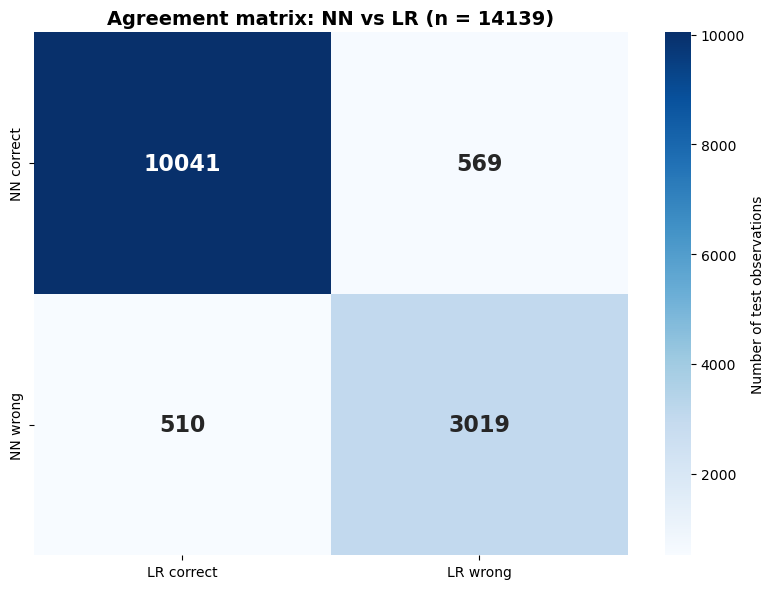

In [25]:
def mcnemar(yA, yB, alpha=0.01):
    cA, cB = yA == 1, yB == 1
    n11 = int((cA &  cB).sum())
    n12 = int((cA & ~cB).sum())
    n21 = int((~cA & cB).sum())
    n22 = int((~cA & ~cB).sum())
    N = len(yA); E = (n12 - n21) / N
    Q = (N**2 * (N+1) * (E+1) * (1-E)) / (N*(n12+n21) - (n12-n21)**2)
    f = (E+1)/2 * (Q-1); g = (1-E)/2 * (Q-1)
    CI = tuple(b*2 - 1 for b in st.beta.interval(1-alpha, a=f, b=g))
    p  = 2 * st.binom.cdf(min(n12, n21), n=n12+n21, p=0.5)
    return E, CI, p, (n11, n12, n21, n22)

E, CI_mc, p_mc, (n11, n12, n21, n22) = mcnemar(nn_correct, lr_correct, alpha=alpha)
N = len(y_true)
print("=" * 60); print(f"McNEMAR TEST  -  n = {N}"); print("=" * 60)
print(f"\n  Both correct:            {n11}")
print(f"  Only NN correct:         {n12}")
print(f"  Only LR correct:         {n21}")
print(f"  Both wrong:              {n22}")
print(f"  Discordant pairs:        {n12 + n21}")
print(f"\n  theta (NN - LR):         {E:+.4f}")
print(f"  {1 - alpha:.0%} CI:                 [{CI_mc[0]:.4f}, {CI_mc[1]:.4f}]")
print(f"  p-value:                 {p_mc:.2e}")
print(f"\n  SIGNIFICANT at alpha = {alpha}" if p_mc < alpha
      else f"\n  NOT significant (p >= {alpha})")
print("=" * 60)

matrix = np.array([[n11, n12], [n21, n22]])
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["LR correct","LR wrong"],
            yticklabels=["NN correct","NN wrong"],
            cbar_kws={"label":"Number of test observations"}, annot_kws={"size":16,"weight":"bold"})
ax.set_title(f"Agreement matrix: NN vs LR (n = {N})", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

## McNemar: distribution of theta

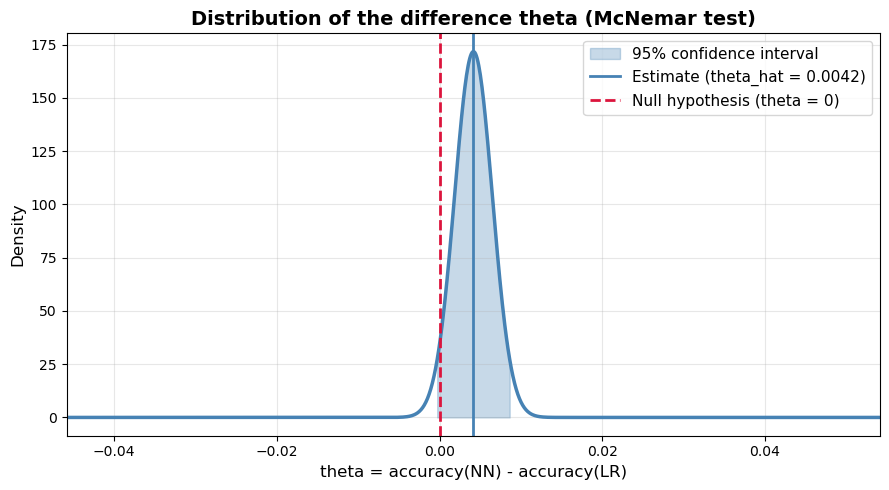

In [26]:
E_plot = (n12 - n21) / N
Q_plot = N**2 * (N + 1) * (E_plot + 1) * (1 - E_plot) / (N * (n12 + n21) - (n12 - n21)**2)
f_plot = (E_plot + 1) / 2 * (Q_plot - 1)
g_plot = (1 - E_plot) / 2 * (Q_plot - 1)

# theta is very close to 0 with this many observations, so zoom in around the estimate
theta = np.linspace(E - 0.05, E + 0.05, 1000)
density = 0.5 * st.beta.pdf((theta + 1) / 2, a=f_plot, b=g_plot)

plt.figure(figsize=(9, 5))
plt.plot(theta, density, color="steelblue", linewidth=2.5)
inside = (theta >= CI_mc[0]) & (theta <= CI_mc[1])
plt.fill_between(theta[inside], density[inside], color="steelblue", alpha=0.3,
                 label=f"{1 - alpha:.0%} confidence interval")
plt.axvline(E, color="steelblue", linewidth=2, label=f"Estimate (theta_hat = {E:.4f})")
plt.axvline(0, color="crimson", linestyle="--", linewidth=2, label="Null hypothesis (theta = 0)")
plt.xlabel("theta = accuracy(NN) - accuracy(LR)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.title("Distribution of the difference theta (McNemar test)", fontsize=14, fontweight="bold")
plt.legend(fontsize=11); plt.grid(alpha=0.3); plt.margins(x=0)
plt.tight_layout(); plt.show()

NN_AC = 0.750406676568357, LR_AC = 0.7462338213452153
NN 95% CI: [0.743, 0.758]
LR 95% CI: [0.739, 0.753]


14139

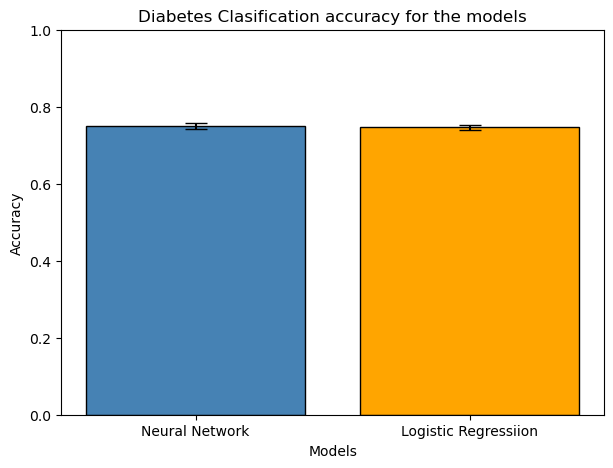

In [30]:
# confidence intervals
import sympy as sp 

test_accuracy_nn = nn_correct.mean()
test_accuracy_LR = lr_correct.mean()

print(f"NN_AC = {test_accuracy_nn}, LR_AC = {test_accuracy_LR}")

len(y_test)

p_nn = test_accuracy_nn
p_LR = test_accuracy_LR

SE_nn= sp.sqrt((p_nn*(1-p_nn)/len(y_test)))
SE_lr= sp.sqrt((p_LR*(1-p_LR)/len(y_test)))

alfa = 0.95
z_alfa_2 = 1.96 

CI_95_NN = p_nn-z_alfa_2*SE_nn, p_nn + z_alfa_2*SE_nn
CI_95_LR = p_LR-z_alfa_2*SE_lr, p_LR + z_alfa_2*SE_lr


print(f"NN 95% CI: [{float(CI_95_NN[0]):.3f}, {float(CI_95_NN[1]):.3f}]")
print(f"LR 95% CI: [{float(CI_95_LR[0]):.3f}, {float(CI_95_LR[1]):.3f}]")


yerr_nn = float(z_alfa_2*SE_nn)
yerr_lr = float(z_alfa_2*SE_lr)

modeller = ["Neural Network", "Logistic Regressiion"]
accuracies = [float(p_nn), float(p_LR)]
MOE = [float(z_alfa_2*SE_nn), float(z_alfa_2*SE_lr)]
plt.figure(figsize=(7,5))
plt.bar(modeller, accuracies, yerr= MOE, capsize=8,
        color=["steelblue", "orange"], edgecolor ="black")
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.title("Diabetes Clasification accuracy for the models")
plt.ylim(0,1)
plt.show


len(y_test)